# Simple Graph 

```txt
start --> Node 1
          /    \ (one conditional edge object with two conditions)
       Node 2  Node 3
          \    / (two normal edges)
           --> end
```

## Graph elements

### State schema

In [1]:
from typing import TypedDict

class State(TypedDict):
    """State schema for the graph."""
    graph_state: str

### Nodes

In [2]:
# Functions for the three nodes 

from typing import Dict


def node_1(state: State) -> Dict:
    """Node 1 function."""
    print("--- Node 1: Start----")
    # 不要直接修改 state["graph_state"]，而是回傳要更新的欄位
    return {"graph_state": state["graph_state"] + " I am"}

def node_2(state: State) -> Dict:
    """Node 2 function."""
    print("--- Node 2 ----")
    return {"graph_state": state["graph_state"] + " happy!"}

def node_3(state: State) -> Dict:
    """Node 3 function."""
    print("--- Node 3 ----")
    return {"graph_state": state["graph_state"] + " sad!"}

### Edge functions for conditional edges

In [3]:
import random
from typing import Literal

def node_1_edge_condition(state: State) -> Literal["node_2", "node_3"]:
    """Edge condition function for Node 1."""
    initial_input_state = state["graph_state"]
    # 可加入較複雜的條件判斷邏輯

    # 使用 random 來模擬條件判斷，50% 機率選擇 node_2 或 node_3
    if random.random() < 0.5:
        return "node_2"
    else:
        return "node_3"
    

## Construct and compile the graph

In [4]:

from langgraph.graph import StateGraph, START, END


builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Add edges to the graph
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", node_1_edge_condition)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Compile the graph
graph = builder.compile()

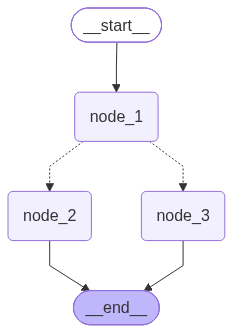

In [5]:
# Display the graph structure
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## Invoke the graph with the initial state

In [6]:
input_state: State = {"graph_state": "Hi, this is Ray."}

# Invoke the graph with the initial state
final_state = graph.invoke(input=input_state)
print("Final state:", final_state)

--- Node 1: Start----
--- Node 3 ----
Final state: {'graph_state': 'Hi, this is Ray. I am sad!'}


In [7]:
# Invoke the second time to see the different path taken
final_state_2 = graph.invoke(input=input_state)
print("Final state (second invocation):", final_state_2)

--- Node 1: Start----
--- Node 2 ----
Final state (second invocation): {'graph_state': 'Hi, this is Ray. I am happy!'}
